In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import random
import json

In [2]:
from grids import make_grid, calc_temp_grid
from init_agents import init_adults
from transitions import maturation, settle, larval_supply
from stages import adult_surv, juvenile_dev, larva_dev

from simulation_core import step, simulate
from RM_statistics import compute_stats

In [3]:
with open("RM_parameters.json") as infile:
    config = json.load(infile)

In [4]:
results = simulate(config)

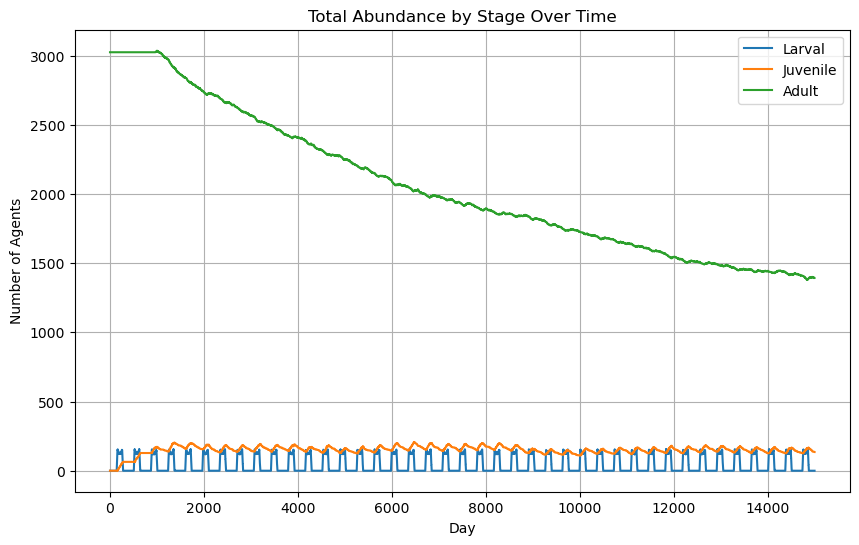

In [5]:
#%%script false --no-raise-error
# -------------------------
# 1. Aggregate counts by Stage and Day
# -------------------------
abundance = results.groupby(['Day', 'Stage'])['Agent_ID'].count().reset_index()
abundance.rename(columns={'Agent_ID': 'Count'}, inplace=True)

# -------------------------
# 2. Pivot for plotting
# -------------------------
abundance_pivot = abundance.pivot(index='Day', columns='Stage', values='Count').fillna(0)

# -------------------------
# 3. Plot
# -------------------------
plt.figure(figsize=(10,6))
for stage in ['Larval', 'Juvenile', 'Adult']:
    if stage in abundance_pivot.columns:
        plt.plot(abundance_pivot.index, abundance_pivot[stage], label=stage)

plt.xlabel('Day')
plt.ylabel('Number of Agents')
plt.title('Total Abundance by Stage Over Time')
plt.legend()
plt.grid(True)
plt.show()

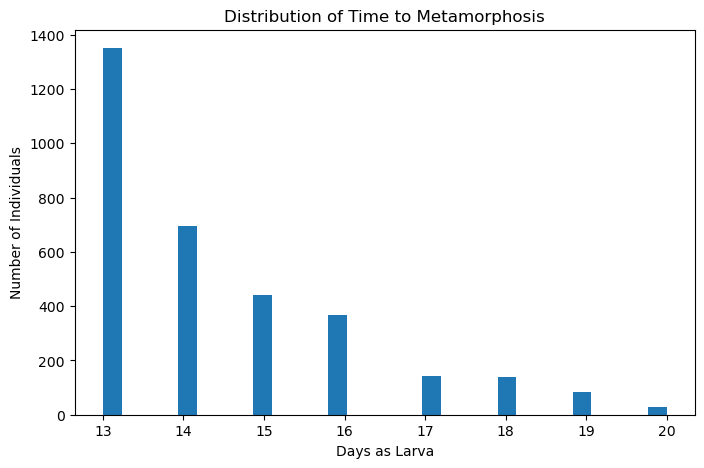

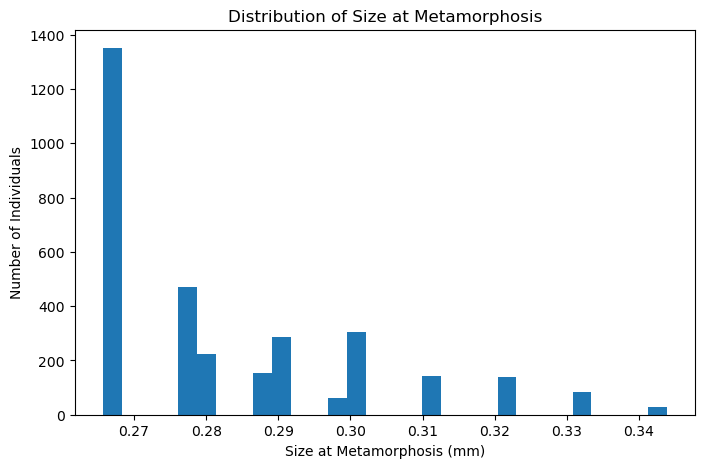

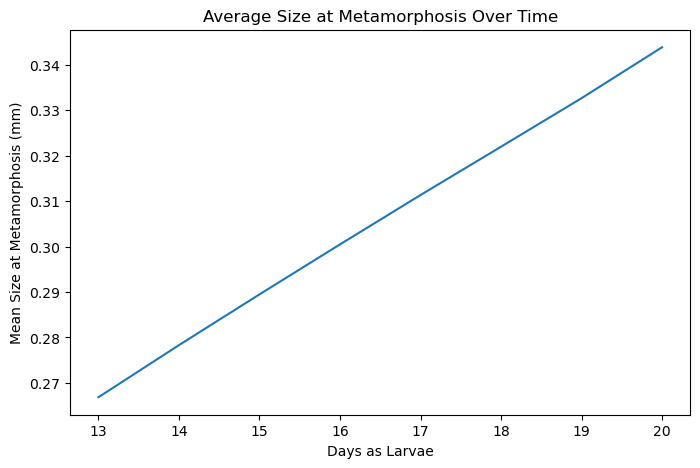

In [6]:
#%%script false --no-raise-error
# ============================================
# Metamorphosis Timing and Size
# Three figures
# ============================================
# --------------------------------------------
# 1. First day as Larval
# --------------------------------------------
larval_first = (
    results[results["Stage"] == "Larval"]
    .groupby("Agent_ID")["Day"]
    .min()
    .rename("Larval_Day")
)

# --------------------------------------------
# 2. First Juvenile record (metamorphosis)
# --------------------------------------------
juvenile_first_records = (
    results[results["Stage"] == "Juvenile"]
    .sort_values("Day")
    .groupby("Agent_ID")
    .first()
)

juvenile_first_records = juvenile_first_records.rename(
    columns={
        "Day": "Juvenile_Day",
        "Size": "Size_at_Metamorphosis"
    }
)[["Juvenile_Day", "Size_at_Metamorphosis"]]

# --------------------------------------------
# 3. Combine and compute duration
# --------------------------------------------
metamorph = pd.concat([larval_first, juvenile_first_records], axis=1)
metamorph = metamorph.dropna()

metamorph["Larval_Duration"] = (
    metamorph["Juvenile_Day"] - metamorph["Larval_Day"]
)

# ============================================
# Plot 1: Days to metamorphosis
# ============================================
plt.figure(figsize=(8,5))
plt.hist(metamorph["Larval_Duration"], bins=30)
plt.xlabel("Days as Larva")
plt.ylabel("Number of Individuals")
plt.title("Distribution of Time to Metamorphosis")
plt.show()

# ============================================
# Plot 2: Size at metamorphosis
# ============================================
plt.figure(figsize=(8,5))
plt.hist(metamorph["Size_at_Metamorphosis"], bins=30)
plt.xlabel("Size at Metamorphosis (mm)")
plt.ylabel("Number of Individuals")
plt.title("Distribution of Size at Metamorphosis")
plt.show()

# ============================================
# Plot 3: Mean size at metamorphosis by day
# ============================================
# Compute mean size for each larval duration
duration_size = (
    metamorph
    .groupby("Larval_Duration")["Size_at_Metamorphosis"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(
    duration_size["Larval_Duration"],
    duration_size["Size_at_Metamorphosis"]
)
plt.xlabel("Days as Larvae")
plt.ylabel("Mean Size at Metamorphosis (mm)")
plt.title("Average Size at Metamorphosis Over Time")
plt.show()

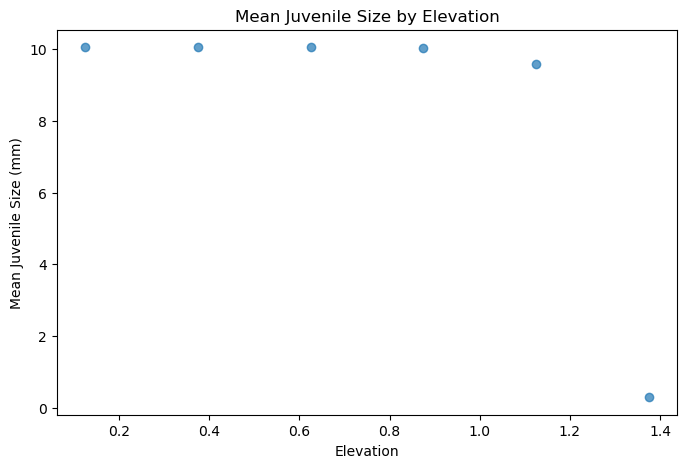

In [7]:
#%%script false --no-raise-error
# ============================================
# Histogram of Mean Juvenile Size by Elevation
# ============================================

# --------------------------------------------
# 1. Filter to Juveniles only
# --------------------------------------------
juveniles = results[results["Stage"] == "Juvenile"].copy()

# Optional: drop missing sizes just in case
juveniles = juveniles.dropna(subset=["Size", "Elevation"])

# --------------------------------------------
# 2. Compute mean size at each elevation
# --------------------------------------------
mean_size_by_elev = (
    juveniles
    .groupby("Elevation")["Size"]
    .mean()
    .reset_index()
)

# --------------------------------------------
# 3. Histogram of mean sizes across elevations
# --------------------------------------------
plt.figure(figsize=(8,5))
plt.scatter(mean_size_by_elev["Elevation"], mean_size_by_elev["Size"], alpha=0.7)
plt.xlabel("Elevation")
plt.ylabel("Mean Juvenile Size (mm)")
plt.title("Mean Juvenile Size by Elevation")
plt.show()

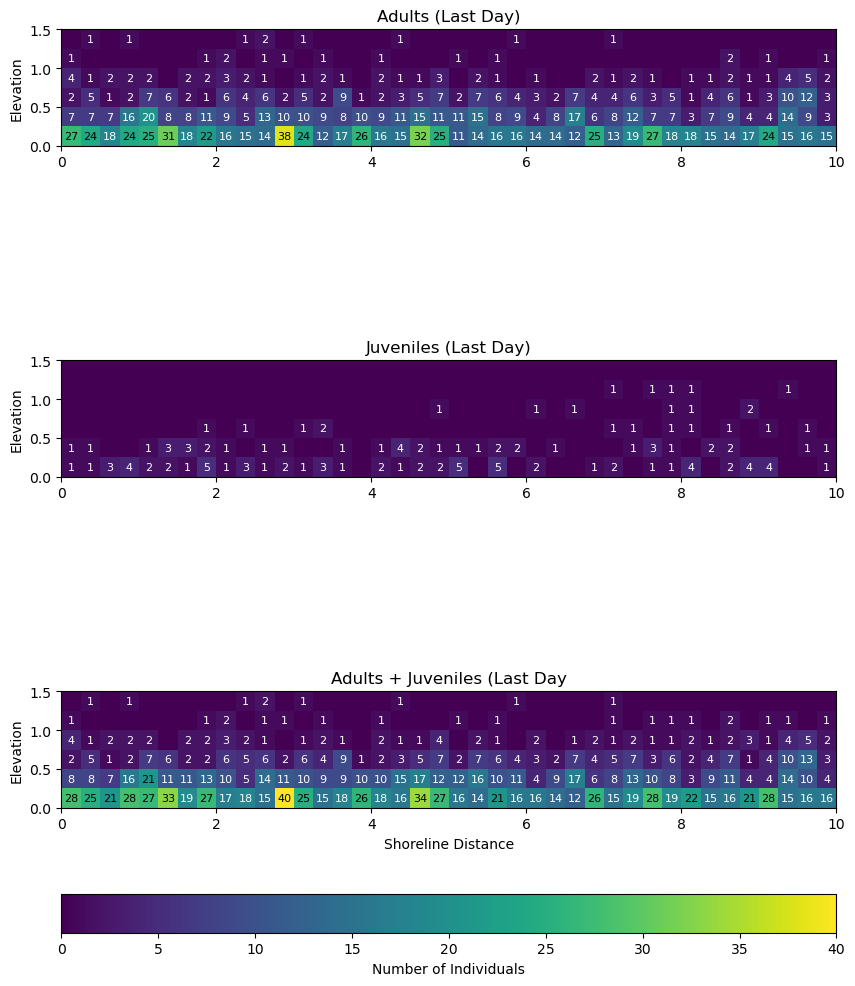

In [8]:

# --- Select last day ---
last_day = results["Day"].max()
df = results[results["Day"] == last_day]

res = config["technical"]["grid_resolution"]

nx = df["Shore_idx"].max() + 1
ny = df["Elev_idx"].max() + 1

adult_grid = np.zeros((ny, nx))
juvenile_grid = np.zeros((ny, nx))

for row in df.itertuples():
    y = row.Elev_idx
    x = row.Shore_idx

    if row.Stage == "Adult":
        adult_grid[y, x] += 1
    elif row.Stage == "Juvenile":
        juvenile_grid[y, x] += 1

total_grid = adult_grid + juvenile_grid

# grid edges
x_edges = np.arange(0, (nx + 1) * res, res)
y_edges = np.arange(0, (ny + 1) * res, res)

# shared color scale
vmax = max(adult_grid.max(), juvenile_grid.max(), total_grid.max())

fig, axes = plt.subplots(3, 1, figsize=(10, 14))

grids = [adult_grid, juvenile_grid, total_grid]
titles = ["Adults (Last Day)", "Juveniles (Last Day)", "Adults + Juveniles (Last Day"]
for ax, grid, title in zip(axes, grids, titles):
    im = ax.pcolormesh(x_edges, y_edges, grid, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_ylabel("Elevation")
    
    # --- Add numbers to each cell ---
    ny_cells, nx_cells = grid.shape
    for i in range(ny_cells):
        for j in range(nx_cells):
            count = int(grid[i, j])
            if count > 0:  # only annotate non-zero cells
                # cell center
                x_center = (x_edges[j] + x_edges[j+1]) / 2
                y_center = (y_edges[i] + y_edges[i+1]) / 2
                ax.text(x_center, y_center, str(count),
                        color="black" if grid[i,j] > vmax/2 else "white",
                        ha="center", va="center", fontsize=8)

axes[2].set_xlabel("Shoreline Distance")

# horizontal colorbar at bottom
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Number of Individuals")

plt.show()

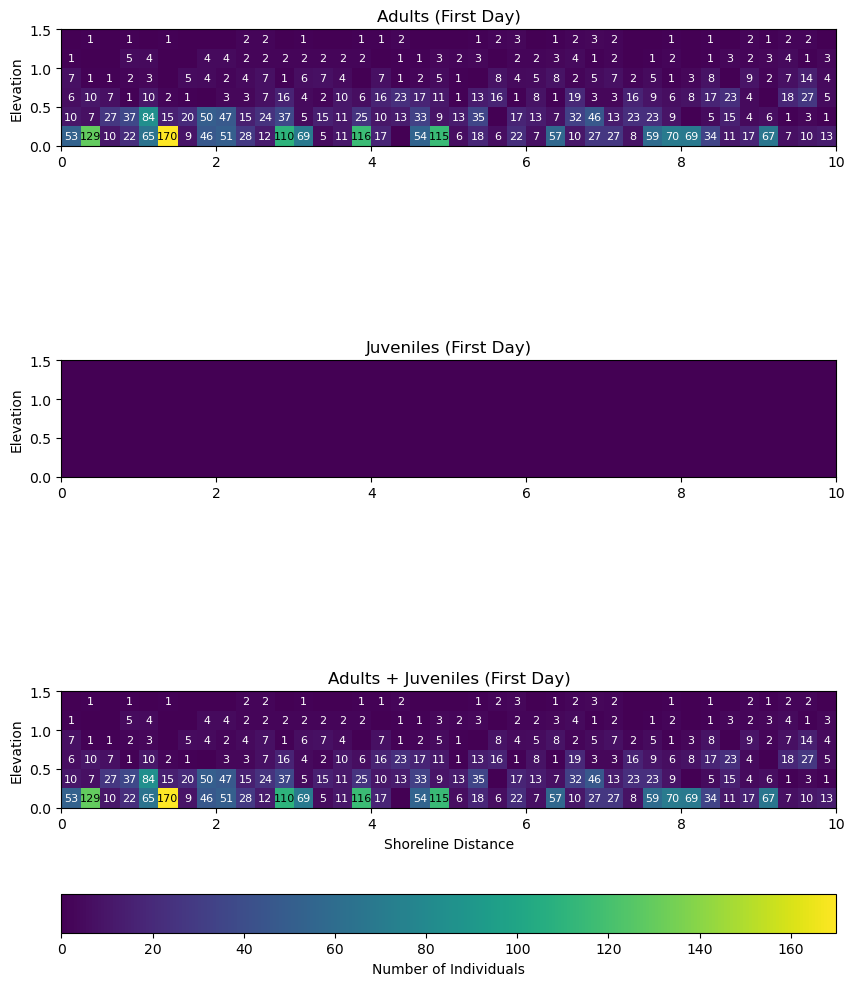

In [9]:
# --- Select first day ---
first_day = results["Day"].min()
df = results[results["Day"] == first_day]

res = config["technical"]["grid_resolution"]

nx = df["Shore_idx"].max() + 1
ny = df["Elev_idx"].max() + 1

adult_grid = np.zeros((ny, nx))
juvenile_grid = np.zeros((ny, nx))

for row in df.itertuples():
    y = row.Elev_idx
    x = row.Shore_idx

    if row.Stage == "Adult":
        adult_grid[y, x] += 1
    elif row.Stage == "Juvenile":
        juvenile_grid[y, x] += 1

total_grid = adult_grid + juvenile_grid

# grid edges
x_edges = np.arange(0, (nx + 1) * res, res)
y_edges = np.arange(0, (ny + 1) * res, res)

# shared color scale
vmax = max(adult_grid.max(), juvenile_grid.max(), total_grid.max())

fig, axes = plt.subplots(3, 1, figsize=(10, 14))

grids = [adult_grid, juvenile_grid, total_grid]
titles = ["Adults (First Day)", "Juveniles (First Day)", "Adults + Juveniles (First Day)"]
for ax, grid, title in zip(axes, grids, titles):
    im = ax.pcolormesh(x_edges, y_edges, grid, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_ylabel("Elevation")
   
    # --- Add numbers to each cell ---
    ny_cells, nx_cells = grid.shape
    for i in range(ny_cells):
        for j in range(nx_cells):
            count = int(grid[i, j])
            if count > 0:  # only annotate non-zero cells
                # cell center
                x_center = (x_edges[j] + x_edges[j+1]) / 2
                y_center = (y_edges[i] + y_edges[i+1]) / 2
                ax.text(x_center, y_center, str(count),
                        color="black" if grid[i,j] > vmax/2 else "white",
                        ha="center", va="center", fontsize=8)

axes[2].set_xlabel("Shoreline Distance")

# horizontal colorbar at bottom
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Number of Individuals")

plt.show()

In [10]:
# -------------------------
# Call function that compute adult parameters
# -------------------------
param_list = []

for day in sorted(results["Day"].unique()):

    day_df = results[results["Day"] == day]

    # Keep only adults
    day_df = day_df[day_df["Stage"] == "Adult"]

    # Skip days with no adults
    if day_df.empty:
        continue

    stats = compute_stats(
        day_df,
        config=config
    )

    if stats.empty:
        continue

    param_list.append({
        "Day": day,
        **stats.iloc[0].to_dict()
    })

param_df = pd.DataFrame(param_list)


PARAMETER TIME SERIES SUMMARY

--- FIRST DAY ---
Day: 0
Abundance: 3025.0000
Density coef: 60.0596
Density exp:  3.0688
Agg coef:     64.4419
Agg exp:      3.7890

--- LAST DAY ---
Day: 15000
Abundance: 1394.0000
Density coef: 28.6703
Density exp:  3.1167
Agg coef:     2.1611
Agg exp:      0.6759


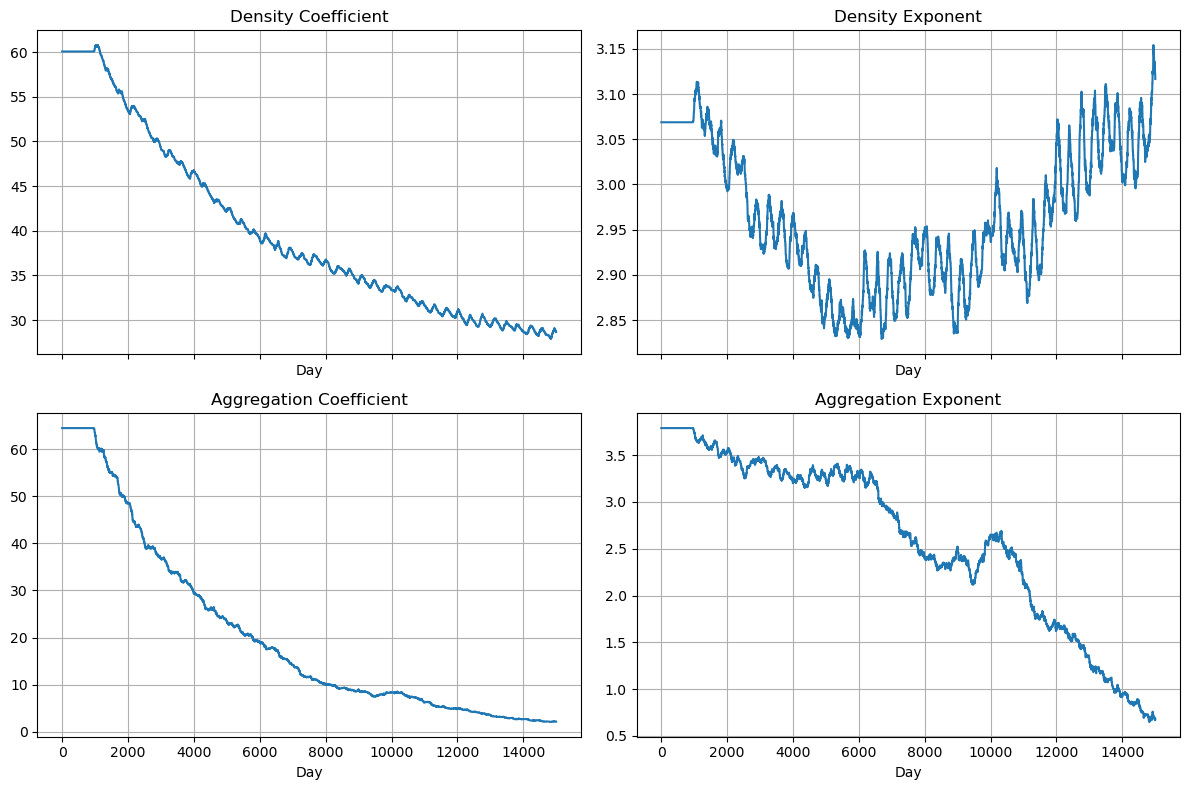

In [11]:
# -------------------------
# PRINT SUMMARY
# -------------------------
print("\n====================================")
print("PARAMETER TIME SERIES SUMMARY")
print("====================================")

first = param_df.iloc[0]
last = param_df.iloc[-1] 

print("\n--- FIRST DAY ---")
print(f"Day: {first['Day']}")
print(f"Abundance: {first['abundance']:.4f}")
print(f"Density coef: {first['density_coef_model']:.4f}")
print(f"Density exp:  {first['density_exp_model']:.4f}")
print(f"Agg coef:     {first['agg_coef_model']:.4f}")
print(f"Agg exp:      {first['agg_exp_model']:.4f}")

print("\n--- LAST DAY ---")
print(f"Day: {last['Day']}")
print(f"Abundance: {last['abundance']:.4f}")
print(f"Density coef: {last['density_coef_model']:.4f}")
print(f"Density exp:  {last['density_exp_model']:.4f}")
print(f"Agg coef:     {last['agg_coef_model']:.4f}")
print(f"Agg exp:      {last['agg_exp_model']:.4f}")

# -------------------------
# plotting
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].plot(param_df["Day"], param_df["density_coef_model"])
axes[0, 0].set_title("Density Coefficient")

axes[0, 1].plot(param_df["Day"], param_df["density_exp_model"])
axes[0, 1].set_title("Density Exponent")

axes[1, 0].plot(param_df["Day"], param_df["agg_coef_model"])
axes[1, 0].set_title("Aggregation Coefficient")

axes[1, 1].plot(param_df["Day"], param_df["agg_exp_model"])
axes[1, 1].set_title("Aggregation Exponent")

for ax in axes.flat:
    ax.set_xlabel("Day")
    ax.grid(True)

plt.tight_layout()
plt.show()